### Extracting Information from text,images,tables inside pdfs

Extracts content from PDFs

* Text
* Tables
* Images

Converts each modality into summaries

* Text → structured chunks

* Tables → summarized descriptions

* Images → vision-based summaries

Stores summaries for retrieval (embedding-ready)

Later → you can query and retrieve relevant info (RAG)

In [ ]:
# Core function:
# Breaks pdf into structured elements: Header, Footer, tittle, Narrative Text, ListItem, Image, Table
raw_pdf_elements=partition_pdf(
    filename="/content/data/cj.pdf",
    strategy="hi_res", #better layout understanding
    extract_images_in_pdf=True,
    extract_image_block_types=["Image", "Table"],
    extract_image_block_to_payload=False,
    extract_image_block_output_dir="extracted_data"
  )

In [ ]:
Header=[]
Footer=[]
Title=[]
NarrativeText=[]
Text=[]
ListItem=[]


for element in raw_pdf_elements:
  if "unstructured.documents.elements.Header" in str(type(element)):
            Header.append(str(element))
  elif "unstructured.documents.elements.Footer" in str(type(element)):
            Footer.append(str(element))
  elif "unstructured.documents.elements.Title" in str(type(element)):
            Title.append(str(element))
  elif "unstructured.documents.elements.NarrativeText" in str(type(element)):
            NarrativeText.append(str(element))
  elif "unstructured.documents.elements.Text" in str(type(element)):
            Text.append(str(element))
  elif "unstructured.documents.elements.ListItem" in str(type(element)):
            ListItem.append(str(element))

Partition pdf stores the unstructured form of tables : storing the flattened form of table contents and in strings
It stores the encoded form of images in binary binary(image)--> using base64 to string

Now tables are not structured in text form also not semantic. So, we summarize the raw form of table returned by the partition_pdf() to get semantic context.

In [ ]:
from langchain_core.output_parsers import StrOutputParser
tab=[]
for element in raw_pdf_elements2:
  if "unstructured.documents.elements.Table" in str(type(element)):
            tab.append(str(element))
model = ChatOpenAI(temperature=0, model="gpt-4")
summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()
table_summaries=summarize_chain.batch(tab,{"max_concurrency": 5})

In [ ]:
import base64
import os
from langchain_core.messages import HumanMessage

In [ ]:
def image_summarize(img_base64, prompt):
    """Make image summary"""


    chat = ChatOpenAI(model="gpt-4-vision-preview", max_tokens=1024)

    msg = chat.invoke(
        [
            HumanMessage(
                content=[
                    {"type": "text", "text": prompt},

                     {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{img_base64}"},
                    },
                ]
            )
        ]
    )
    return msg.content

In [ ]:
def generate_img_summaries(path):
    """
    Generate summaries and base64 encoded strings for images
    path: Path to list of .jpg files extracted by Unstructured
    """

    # Store base64 encoded images
    img_base64_list = []

    # Store image summaries
    image_summaries = []

    # Prompt
    prompt = """You are an assistant tasked with summarizing images for retrieval. \
    These summaries will be embedded and used to retrieve the raw image. \
    Give a concise summary of the image that is well optimized for retrieval."""


    base64_image = encode_image(path)
    img_base64_list.append(base64_image)
    image_summaries.append(image_summarize(base64_image, prompt))

    return img_base64_list, image_summaries

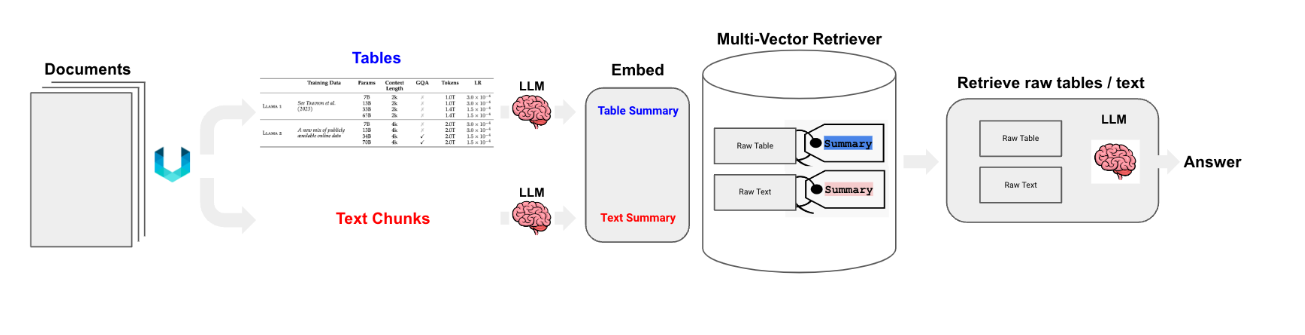

Mapping summary to raw table helps us query on summary . then passing the raw form associated with it to llm for answers

## Creating a Multi-Vector Retriever

In [ ]:
import uuid

from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain.storage import InMemoryStore
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings

1) Vector Stores (Chroma) stores "summary of tables" , "image showing architecture"
2) Doc Stores (InMemoryStore) stores (doc_id-->actual_content raw)
Connection via doc_id

Document(page_content=summary, metadata={"doc_id": id})

This links:

Summary (for search)

Raw data (for retrieval)

In [ ]:
def create_multi_vector_retriever(vectorstore, text_summaries, texts, table_summaries, tables, image_summaries, images):
    """
    Create retriever that indexes summaries, but returns raw images or texts
    """

    # Initialize the storage layer
    store = InMemoryStore()
    id_key = "doc_id"

    # Create the multi-vector retriever
    retriever = MultiVectorRetriever(
        vectorstore=vectorstore,
        docstore=store,
        id_key=id_key,
    )


    # Helper function to add documents to the vectorstore and docstore
    def add_documents(retriever, doc_summaries, doc_contents):

      doc_ids = [str(uuid.uuid4()) for _ in doc_contents]

      summary_docs = [
              Document(page_content=s, metadata={id_key: doc_ids[i]})
              for i, s in enumerate(doc_summaries)
          ]

      retriever.vectorstore.add_documents(summary_docs)
      retriever.docstore.mset(list(zip(doc_ids, doc_contents)))

      # Add texts, tables, and images
      # Check that text_summaries is not empty before adding
      if text_summaries:
         add_documents(retriever, text_summaries, texts)
      # Check that table_summaries is not empty before adding
      if table_summaries:
          add_documents(retriever, table_summaries, tab)
      # Check that image_summaries is not empty before adding
      if image_summaries:
          add_documents(retriever, image_summaries, img)

    return retriever

vectorstore = Chroma(
    collection_name="mm_rag", embedding_function=OpenAIEmbeddings()
)

# Create retriever
retriever_multi_vector_img = create_multi_vector_retriever(
    vectorstore,
    text_summaries,
    Text,
    table_summaries,
    Table,
    image_summaries,
    img_base64_list,
)

{
  "context": {

    "texts": [...],     # raw text + table content
    "images": [...]     # base64 images
  },
  "question": "user query"
}

This is passed to below function normal python dict


This function returns:

HumanMessage(content=[

  Images first
  {"type": "image_url", "image_url": {...}},
  {"type": "image_url", "image_url": {...}},

  Then text
  {"type": "text", "text": "...question + context..."}
])

Retrieve using summaries → Answer using raw multimodal data

In [ ]:
def img_prompt_func(data_dict):
    """
    Join the context into a single string
    """
    #print(data_dict)
    formatted_texts = "\n".join(data_dict["context"]["texts"])
    messages = []

    # Adding image(s) to the messages if present
    if data_dict["context"]["images"]:
        for image in data_dict["context"]["images"]:
            image_message = {
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{image}"},
            }
            messages.append(image_message)

    # Adding the text for analysis
    text_message = {
        "type": "text",
        "text": (
            "You are a helpful assistant.\n"
            "You will be given a mixed info(s) .\n"
            "Use this information to provide relevant information to the user question. \n"
            f"User-provided question: {data_dict['question']}\n\n"
            "Text and / or tables:\n"
            f"{formatted_texts}"
        ),
    }
    messages.append(text_message)
    return [HumanMessage(content=messages)]

In [ ]:
from langchain_core.runnables import RunnableLambda, RunnablePassthrough

In [ ]:
def multi_modal_rag_chain(retriever):
    """
    Multi-modal RAG chain
    """

    # Multi-modal LLM
    model = ChatOpenAI(temperature=0, model="gpt-4-vision-preview", max_tokens=1024)


    # RAG pipeline
    chain = (
        {
            "context": retriever | RunnableLambda(split_image_text_types), #This is a Runnable Map (dictionary pipeline). It means: Take one input → produce multiple outputs in parallel”
            "question": RunnablePassthrough(), "the actual question passing as input" # A function that returns the input unchanged Equivalent to: lambda x: x
            # Why is it needed? Because: You want to: Use input for retrieval , ALSO pass original question forward Without it: Question would be lost
            #Because LangChain pipelines require: Everything to be a Runnable Not raw values
        }
        | RunnableLambda(img_prompt_func)
        | model
        | StrOutputParser()
    )

    return chain

User input:
"What is the architecture?"

        ┌───────────────┐
        │ Runnable Map  │
        └──────┬────────┘
               │

parallely : context branch         question branch

(retriever)            (passthrough)

{texts, images}     "What is the architecture?"

        ↓
Combine into dict

        ↓
img_prompt_func

        ↓
HumanMessage

        ↓
Vision LLM

        ↓
Final Answer

## Know about multimodal databases:

### AstraDB
*   Managed cloud database built on Cassandra
*   Supports vector search + metadata + scalability
* Store embeddings (summaries)
* Store metadata (doc_id, type=image/table/text)

### LanceDB

* Lightweight vector database
* Built on columnar storage (Apache Arrow)
* Runs locally (no cloud needed)

### Google Gemini (Multimodal brain)

* Multimodal LLM (text + image + video)
* Native multimodal understanding (unlike older GPT setups)
* we can easily skip summarization


